# 1 — Hidden Markov models and mixed-state presentations

**Worked solutions · draft for the Iliad Intensive**

A small hidden generator can create a surprisingly complicated
prediction problem. In this notebook you will derive that claim,
rather than implement an HMM library.

By the end, you should be able to:

- read an edge-emitting HMM diagram and its symbol-labelled matrices;
- calculate word probabilities by multiplying matrices;
- derive posterior beliefs and their recursive Bayesian update;
- turn a belief into probabilities for any future word;
- explain the mixed-state presentation (MSP) as dynamics in a
  probability simplex;
- exhibit two beliefs that agree about the next token but disagree
  about the longer future.

**Route through the notebook:** four numbered **CORE** problems plus
the Mess3 **CORE SYNTHESIS** form the 60–70 minute path. **STRETCH**
and **DESIGN STUDIO** boxes are modular: skip them without breaking
the argument.

**Working mode.** Most answers are mathematics. Code cells marked
**visual/check** are supplied plumbing: run them, inspect the result,
and return to the derivation. No Python knowledge is assumed.


> <span lang="la">*longum iter est per praecepta, breve et efficax per exempla. multum interest utrum non velit an nesciat. velle non discitur.*</span>
>
> — **Seneca the Younger**, adapted from *Moral Letters to Lucilius* 6.5, 90.46, and 81.13


## The running process: Zero–One–Random

The process repeatedly emits `0`, then `1`, then a random bit, and
repeats. At time $t$, $S_t$ is the hidden phase **before** the next
edge. Traversing that edge emits $X_{t+1}$ and arrives at
$S_{t+1}$. The three phases are:

- $S_0$: emit `0`, then arrive at $S_1$;
- $S_1$: emit `1`, then arrive at $S_R$;
- $S_R$: emit a fair random bit, then arrive at $S_0$.

An edge $S_i \xrightarrow{x:p} S_j$ means the **joint** event

$$
\Pr(X_{t+1}=x,S_{t+1}=S_j\mid S_t=S_i)=p.
$$

We use row vectors for distributions. You will reconstruct the
symbol matrices from the picture before they are revealed.


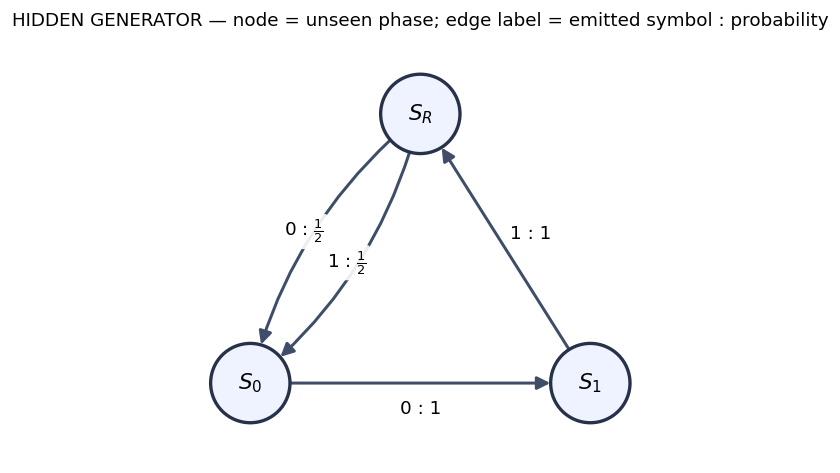

In [1]:
# VISUAL / CHECK — run this cell; there is nothing to edit.
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

np.set_printoptions(precision=4, suppress=True)

def draw_z1r():
    pos = {
        r"$S_0$": np.array([0.0, 0.0]),
        r"$S_1$": np.array([2.4, 0.0]),
        r"$S_R$": np.array([1.2, 1.9]),
    }
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    for name, xy in pos.items():
        ax.add_patch(Circle(xy, 0.28, facecolor="#eef3ff",
                            edgecolor="#27324a", lw=2, zorder=3))
        ax.text(*xy, name, ha="center", va="center", fontsize=13,
                zorder=4)

    def arrow(a, b, label, rad=0.0, offset=(0, 0)):
        patch = FancyArrowPatch(
            pos[a], pos[b], arrowstyle="-|>", mutation_scale=16,
            shrinkA=24, shrinkB=24, lw=1.8, color="#3f4d68",
            connectionstyle=f"arc3,rad={rad}",
        )
        ax.add_patch(patch)
        mid = (pos[a] + pos[b]) / 2 + np.array(offset)
        ax.text(*mid, label, ha="center", va="center", fontsize=11,
                bbox=dict(boxstyle="round,pad=.2", fc="white",
                          ec="none", alpha=.9))

    arrow(r"$S_0$", r"$S_1$", "0 : 1", offset=(0, -.18))
    arrow(r"$S_1$", r"$S_R$", "1 : 1", offset=(.18, .10))
    arrow(r"$S_R$", r"$S_0$", r"0 : $\frac{1}{2}$", rad=.17,
          offset=(-.22, .12))
    arrow(r"$S_R$", r"$S_0$", r"1 : $\frac{1}{2}$", rad=-.17,
          offset=(.08, -.10))
    ax.set(xlim=(-.6, 3.0), ylim=(-.55, 2.45), aspect="equal")
    ax.axis("off")
    ax.set_title(
        "HIDDEN GENERATOR — node = unseen phase; "
        "edge label = emitted symbol : probability",
        fontsize=11,
    )
    plt.show()

draw_z1r()


### Reading convention

Rows mean the phase **before** an edge and columns mean the phase
**after** it. For symbol $x\in\{0,1\}$, define

$$
T^{(x)}_{ij}
=\Pr(X_{t+1}=x,S_{t+1}=S_j\mid S_t=S_i).
$$

A symbol matrix is not generally row-stochastic: it contains only
the joint events that emit that symbol. Normalization applies only
after summing over both possible symbols.


## CORE 1/4 — Reconstruct the generator (10 minutes)

1. Without looking at code, reconstruct the complete $3\times3$
   matrices $T^{(0)}$ and $T^{(1)}$ from the diagram.
2. Derive the normalization identity

   $$
   \sum_{x\in\{0,1\}}\sum_j T^{(x)}_{ij}=1
   \quad\text{for each source state }i.
   $$

   Explain why it does **not** require either symbol matrix to have
   row sums equal to one.
3. Let $T=T^{(0)}+T^{(1)}$. Verify that the uniform row vector
   $\pi=(1/3,1/3,1/3)$ is stationary: $\pi T=\pi$.
4. Use the diagram or your matrices to calculate
   $\Pr(X_1=0)$ under $\pi$, keeping the two hidden-source
   contributions visible.

<details><summary>Hint 1</summary>
Each arrow contributes to exactly one entry of exactly one symbol
matrix.
</details>

<details><summary>Hint 2</summary>
Stationarity is a statement about the state-transition matrix
$T$, after forgetting which symbol was emitted.
</details>


#### Worked solution

Reading each labelled edge gives

$$
T^{(0)}=
\begin{pmatrix}
0&1&0\\
0&0&0\\
1/2&0&0
\end{pmatrix},
\qquad
T^{(1)}=
\begin{pmatrix}
0&0&0\\
0&0&1\\
1/2&0&0
\end{pmatrix}.
$$

Summing over every mutually exclusive emitted-symbol/destination
pair exhausts the possible next edges, which proves the
normalization identity. For instance, the zero second row of
$T^{(0)}$ is harmless because all of that row's mass sits in
$T^{(1)}$.

Adding the matrices gives
$T=\left(\begin{smallmatrix}0&1&0\\0&0&1\\1&0&0\end{smallmatrix}\right)$.
It cyclically permutes the three coordinates, so
$\pi T=\pi$. Finally,

   $$
   \Pr(X_1=0)
   =\pi T^{(0)}\mathbf 1
   =\frac13+\frac16=\frac12.
   $$
   The two contributions are “we were in $S_0$” and “we were in
   $S_R$ and its fair bit was zero”.


In [2]:
# POST-ANSWER CHECK / SETUP — matrices are revealed only after CORE 1.
T0 = np.array([
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.5, 0.0, 0.0],
])
T1 = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.5, 0.0, 0.0],
])
T = np.stack([T0, T1])
eta_empty = np.ones(3) / 3

print("T^(0) =\n", T0)
print("T^(1) =\n", T1)
print("row sums after adding symbols:", T.sum(axis=(0, 2)))


T^(0) =
 [[0.  1.  0. ]
 [0.  0.  0. ]
 [0.5 0.  0. ]]
T^(1) =
 [[0.  0.  0. ]
 [0.  0.  1. ]
 [0.5 0.  0. ]]
row sums after adding symbols: [1. 1. 1.]


### Notation card — keep this visible

| Symbol | Meaning | Shape |
|---|---|---|
| $\pi=\eta^{(\epsilon)}$ | stationary belief before any observed symbol | $1\times3$ row |
| $\mathbf 1=(1,1,1)^\top$ | sums over the unknown final hidden state | $3\times1$ column |
| $T^{(w)}=T^{(x_1)}\cdots T^{(x_L)}$ | all hidden paths that emit $w=x_1\cdots x_L$ | $3\times3$ |
| $\alpha^{(w)}_j=\Pr(w,S_L=S_j)$ | unnormalized forward row | $1\times3$ |
| $\eta^{(w)}_j=\Pr(S_L=S_j\mid w)$ | normalized posterior belief | $1\times3$ |

The superscript $(w)$ labels an observed word; it is not a matrix
power. From here on, $\epsilon$ denotes the empty history.


## CORE 2/4 — From hidden paths to word probabilities (14 minutes)

Let $w=x_1x_2\ldots x_L$ be an observed word and write
$T^{(w)}=T^{(x_1)}T^{(x_2)}\cdots T^{(x_L)}$.

1. For a two-symbol word $x_1x_2$, begin with a sum over the unknown
   hidden states $s_0,s_1,s_2$. Regroup the factors until you can
   recognize matrix multiplication.
2. Generalize the result to show that the forward row obeys

   $$
   \alpha^{(wx)}=\alpha^{(w)}T^{(x)},\qquad
   \Pr(w)=\alpha^{(w)}\mathbf 1
   =\pi T^{(w)}\mathbf 1.
   $$

3. Use either hidden paths or the formula to calculate
   $\Pr(01)$, $\Pr(00)$, and $\Pr(010)$ for Z1R.
4. Explain what information $\alpha^{(w)}$ retains that the scalar
   $\Pr(w)$ discards.

<details><summary>Hint 1</summary>
For fixed $s_0,s_1,s_2$, the path contribution is
$\eta_{s_0}T^{(x_1)}_{s_0s_1}T^{(x_2)}_{s_1s_2}$.
</details>

<details><summary>Hint 2</summary>
The final multiplication by $\mathbf 1$ sums over the unknown final
hidden state.
</details>


#### Worked solution

For two symbols,

$$
\begin{aligned}
\Pr(x_1x_2)
&=\sum_{s_0,s_1,s_2}
  \eta_{s_0}^{(\emptyset)}
  T^{(x_1)}_{s_0s_1}T^{(x_2)}_{s_1s_2}\\
&=\eta^{(\emptyset)}T^{(x_1)}T^{(x_2)}\mathbf 1.
\end{aligned}
$$

Repeating the same marginalization at each hidden step gives
$\alpha^{(w)}=\pi T^{(w)}$ and
$\alpha^{(wx)}=\alpha^{(w)}T^{(x)}$. Summing its destination-state
coordinate gives $\Pr(w)=\alpha^{(w)}\mathbf 1$.

For `01`, the only nonzero stationary path begins in $S_0$, so
$\Pr(01)=1/3$. For `00`, the process must begin in $S_R$, emit its
random zero, and then emit the certain zero from $S_0$, so
$\Pr(00)=(1/3)(1/2)=1/6$. After `01` the process is at $S_R$,
which emits `0` with probability $1/2$, so
$\Pr(010)=1/6$.

The scalar word probability forgets where a compatible hidden path
ended. The forward row retains the joint mass assigned to each
possible final phase, which is exactly what the next update needs.


In [3]:
# CHECK — compare the matrix calculation with your arithmetic.
def forward(word, initial=eta_empty, transition_tensor=T):
    vector = np.asarray(initial, dtype=float)
    for symbol in word:
        vector = vector @ transition_tensor[int(symbol)]
    return vector

def word_probability(word, initial=eta_empty, transition_tensor=T):
    return float(forward(word, initial, transition_tensor).sum())

for word in ["0", "1", "00", "01", "10", "11"]:
    print(f"P({word}) = {word_probability(word):.6f}")


P(0) = 0.500000
P(1) = 0.500000
P(00) = 0.166667
P(01) = 0.333333
P(10) = 0.333333
P(11) = 0.166667


## CORE 3/4 — Bayes as a recursive geometric map (20 minutes)

After observing $w$, define the **belief state**

$$
\eta^{(w)}_j=\Pr(S_{\lvert w\rvert}=S_j\mid X_{1:\lvert w\rvert}=w).
$$

1. Use $\alpha^{(w)}$ to derive

   $$
   \eta^{(w)}
   =\frac{\alpha^{(w)}}{\alpha^{(w)}\mathbf1}
   =\frac{\pi T^{(w)}}{\pi T^{(w)}\mathbf1}.
   $$

2. Now suppose the current belief is an arbitrary row $\eta$ and
   the next observed symbol is $x$. Derive the recursive map

   $$
   F_x(\eta)=\frac{\eta T^{(x)}}
   {\eta T^{(x)}\mathbf1},
   $$

   and interpret its denominator probabilistically.
3. Calculate $\eta^{(0)}$, $\eta^{(01)}$, and $\eta^{(10)}$ by
   composing these maps. Check explicitly that the order matters:
   $F_1(F_0(\pi))\ne F_0(F_1(\pi))$.
4. Where do all three-component beliefs live geometrically? Why is
   $F_x$ generally rational rather than linear, even though its
   numerator is linear?

<details><summary>Hint 1</summary>
Bayes' rule divides the joint row
$(\Pr(w,S_L=S_j))_j$ by its total mass.
</details>

<details><summary>Hint 2</summary>
Treat the current posterior as the next step's prior. Compare
histories `01` and `10`, rather than recomputing `01` twice.
</details>


#### Worked solution

Bayes' rule normalizes the forward row:

$$
\eta^{(w)}
=\frac{\alpha^{(w)}}{\alpha^{(w)}\mathbf1}
=\frac{\pi T^{(w)}}{\pi T^{(w)}\mathbf1}.
$$

Reusing a posterior as the next prior makes the unnormalized
destination row $\eta T^{(x)}$. Its mass is
$\eta T^{(x)}\mathbf1=\Pr(X_{\mathrm{next}}=x\mid\eta)$, so dividing
by it gives $F_x$.

For `0` and the two orderings,

$$
\eta^{(0)}
=\frac{(1/6,1/3,0)}{1/2}
=(1/3,2/3,0),\qquad
\eta^{(01)}=(0,0,1),
$$

while

$$
\eta^{(1)}=(1/3,0,2/3),\qquad
\eta^{(10)}=(1/2,1/2,0).
$$

Thus the two update orders land at different points. Every belief
is nonnegative and sums to one, so beliefs live in the triangular
simplex $\Delta^2$. Division by the belief-dependent observation
probability makes $F_x$ rational rather than linear.


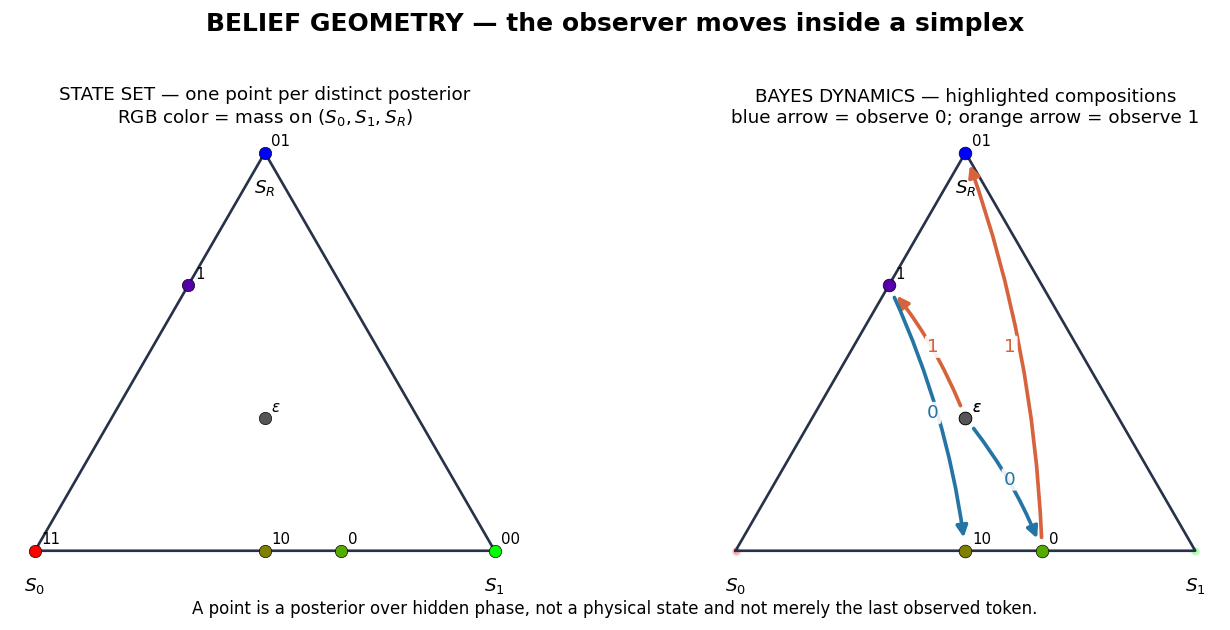

31 reachable histories collapse to 7 distinct belief states.


In [4]:
# VISUAL / CHECK — reachable Z1R beliefs in the hidden-state simplex.
simplex_vertices = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.5, np.sqrt(3) / 2],
])

def belief(word, initial=eta_empty, transition_tensor=T):
    unnormalized = forward(word, initial, transition_tensor)
    mass = unnormalized.sum()
    if mass <= 1e-14:
        raise ValueError(f"Impossible history: {word}")
    return unnormalized / mass

def reachable_beliefs(alphabet, max_depth, initial, tensor):
    result = {"": np.asarray(initial, dtype=float)}
    for depth in range(1, max_depth + 1):
        for symbols in itertools.product(alphabet, repeat=depth):
            word = "".join(map(str, symbols))
            if word_probability(word, initial, tensor) > 1e-14:
                result[word] = belief(word, initial, tensor)
    return result

z1r_beliefs = reachable_beliefs([0, 1], 5, eta_empty, T)
belief_groups = {}
for word, b in z1r_beliefs.items():
    key = tuple(np.round(b, 10))
    belief_groups.setdefault(key, {"belief": b, "histories": []})
    belief_groups[key]["histories"].append(word)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.2))
triangle = np.vstack([simplex_vertices, simplex_vertices[0]])
for ax in axes:
    ax.plot(triangle[:, 0], triangle[:, 1],
            color="#27324a", lw=1.6)
    for label, xy in zip([r"$S_0$", r"$S_1$", r"$S_R$"],
                         simplex_vertices):
        ax.text(*(xy + np.array([0.0, -.055])), label,
                ha="center", va="top", fontsize=11)
    ax.set_aspect("equal")
    ax.axis("off")

# Left: the state set, uncluttered.
for group in belief_groups.values():
    b = group["belief"]
    xy = b @ simplex_vertices
    representative = min(
        group["histories"], key=lambda word: (len(word), word)
    )
    label = r"$\epsilon$" if representative == "" else representative
    axes[0].scatter(*xy, s=55, color=b, edgecolor="black",
                    linewidth=.4, zorder=3)
    axes[0].annotate(label, xy, xytext=(4, 4),
                     textcoords="offset points", fontsize=9)
axes[0].set_title(
    "STATE SET — one point per distinct posterior\n"
    "RGB color = mass on $(S_0,S_1,S_R)$",
    fontsize=11,
)

# Right: only two update paths, so the arrows remain legible.
for group in belief_groups.values():
    b = group["belief"]
    axes[1].scatter(*(b @ simplex_vertices), s=25, color=b,
                    alpha=.28, linewidth=0, zorder=1)

symbol_colors = {"0": "#2474a6", "1": "#d6633c"}
for path in [["", "0", "01"], ["", "1", "10"]]:
    for source_word, target_word in zip(path[:-1], path[1:]):
        start = belief(source_word) @ simplex_vertices
        destination = belief(target_word) @ simplex_vertices
        symbol = target_word[-1]
        axes[1].add_patch(FancyArrowPatch(
            start, destination, arrowstyle="-|>",
            mutation_scale=14, shrinkA=8, shrinkB=8, lw=2.2,
            color=symbol_colors[symbol],
            connectionstyle=f"arc3,rad={-.08 if symbol == '0' else .08}",
            zorder=3,
        ))
        midpoint = (start + destination) / 2
        axes[1].text(*midpoint, symbol, fontsize=11,
                     color=symbol_colors[symbol],
                     bbox=dict(boxstyle="round,pad=.12",
                               fc="white", ec="none", alpha=.9))
    for word in path:
        xy = belief(word) @ simplex_vertices
        axes[1].scatter(*xy, s=58, color=belief(word),
                        edgecolor="black", linewidth=.4, zorder=4)
        axes[1].annotate(
            r"$\epsilon$" if word == "" else word,
            xy, xytext=(4, 4), textcoords="offset points",
            fontsize=9,
        )
axes[1].set_title(
    "BAYES DYNAMICS — highlighted compositions\n"
    "blue arrow = observe 0; orange arrow = observe 1",
    fontsize=11,
)
fig.suptitle(
    "BELIEF GEOMETRY — the observer moves inside a simplex",
    fontsize=15, fontweight="bold",
)
fig.text(
    .5, .015,
    "A point is a posterior over hidden phase, not a physical state "
    "and not merely the last observed token.",
    ha="center", fontsize=10,
)
plt.tight_layout(rect=(0, .05, 1, .92))
plt.show()

print(f"{len(z1r_beliefs)} reachable histories collapse to "
      f"{len(belief_groups)} distinct belief states.")


The **mixed-state presentation** is the inference process whose
states are reachable beliefs and whose symbol-labelled transitions
are the maps $F_x$. The original HMM describes how the hidden world
generates data; the MSP describes how an observer updates uncertainty
about that world.

The plot labels states by histories for convenience, but the state
itself is the posterior vector. Two histories that yield the same
posterior land at the same point.


## CORE 4/4 — Same next token, different future (15 minutes)

From a belief $\eta$, the probability of a future word
$u=u_1\ldots u_k$ is

$$
\Pr(u\mid\eta)=\eta T^{(u)}\mathbf 1.
$$

1. Derive the next-token map
   $\Pr(X_{\mathrm{next}}=x\mid\eta)=\eta T^{(x)}\mathbf 1$.
2. Calculate the two beliefs $\eta^{(01)}$ and $\eta^{(10)}$.
3. Show that both give the next-token distribution $(1/2,1/2)$.
4. For each belief, calculate the distribution over
   `00`, `01`, `10`, and `11`.
5. Explain precisely what fails if the next-token vector is the
   **only recursively retained state**. Why does this not imply that
   a full-context model must literally store an HMM posterior?

<details><summary>Hint 1</summary>
You already found $\eta^{(01)}$. For `10`, propagate one symbol at a
time and normalize.
</details>

<details><summary>Hint 2</summary>
Under $\eta^{(01)}$ the hidden state is certainly $S_R$; under
$\eta^{(10)}$ it is an equal mixture of $S_0$ and $S_1$.
</details>


#### Worked solution

Summing the unnormalized destination distribution gives
$\Pr(x\mid\eta)=\eta T^{(x)}\mathbf 1$. More generally, retaining the
later hidden path gives $\Pr(u\mid\eta)=\eta T^{(u)}\mathbf 1$.

The two beliefs are

$$
\eta^{(01)}=(0,0,1),\qquad
\eta^{(10)}=(1/2,1/2,0).
$$

The first is certainly at $S_R$; the second is equally likely to be
at $S_0$ or $S_1$. Both emit `0` and `1` with probability $1/2$.
Their two-step predictions differ:

$$
\begin{array}{c|cccc}
&00&01&10&11\\\hline
\eta^{(01)}&1/2&0&1/2&0\\
\eta^{(10)}&0&1/2&1/4&1/4
\end{array}
$$

If the next-token vector were the predictor's sole recursively
retained state, these histories would be merged. Feeding the same
next symbol into the same state-update rule would then produce the
same later prediction, contradicting the table.

This is an insufficiency result about a particular state
compression. A full-context model can revisit the whole prefix, and
any model may encode the needed distinction in coordinates other
than our HMM posterior. The result motivates a search for richer
predictive information; it does not dictate how a transformer must
represent it.


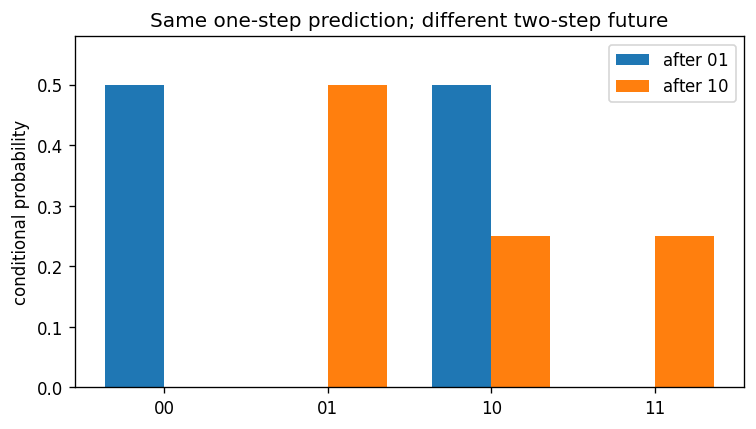

belief after 01: [0. 0. 1.]
belief after 10: [0.5 0.5 0. ]
next-token distributions: [0.5 0.5] [0.5 0.5]


In [5]:
# VISUAL / CHECK — compare the two future distributions.
eta_01 = belief("01")
eta_10 = belief("10")
future_words = ["00", "01", "10", "11"]

def future_distribution(current_belief, words, tensor=T):
    return np.array([
        word_probability(w, current_belief, tensor) for w in words
    ])

next_01 = future_distribution(eta_01, ["0", "1"])
next_10 = future_distribution(eta_10, ["0", "1"])
two_01 = future_distribution(eta_01, future_words)
two_10 = future_distribution(eta_10, future_words)

print("belief after 01:", eta_01)
print("belief after 10:", eta_10)
print("next-token distributions:", next_01, next_10)

x = np.arange(len(future_words))
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.bar(x - .18, two_01, .36, label=r"after $01$")
ax.bar(x + .18, two_10, .36, label=r"after $10$")
ax.set(xticks=x, xticklabels=future_words, ylim=(0, .58),
       ylabel="conditional probability",
       title="Same one-step prediction; different two-step future")
ax.legend()
plt.show()


## CORE SYNTHESIS — Build the Mess3 recursion (10 minutes)

Z1R has only a small set of recurrent beliefs. The same update rule
can instead generate a fractal set. Mess3 still has only three
**hidden generator states**, but it has three observation symbols and
three contracting, renormalizing belief maps. For the parameters used
here, its visible symbol matrices are

$$
T^{(0)}=
\begin{pmatrix}
.14&.06&.06\\ .03&.28&.06\\ .03&.06&.28
\end{pmatrix},\quad
T^{(1)}=
\begin{pmatrix}
.28&.03&.06\\ .06&.14&.06\\ .06&.03&.28
\end{pmatrix},
$$

$$
T^{(2)}=
\begin{pmatrix}
.28&.06&.03\\ .06&.28&.03\\ .06&.06&.14
\end{pmatrix},\qquad
\eta^{(\epsilon)}=(1/3,1/3,1/3).
$$

For a simplex vertex $e_i$ (certainty about hidden state $i$),

$$
F_x(e_i)=\frac{e_iT^{(x)}}{e_iT^{(x)}\mathbf1}
$$

is just the normalized $i$th row of $T^{(x)}$. The first supplied
visual draws only the three image triangles $F_x(\Delta^2)$; it does
**not** reveal the length-two answers.


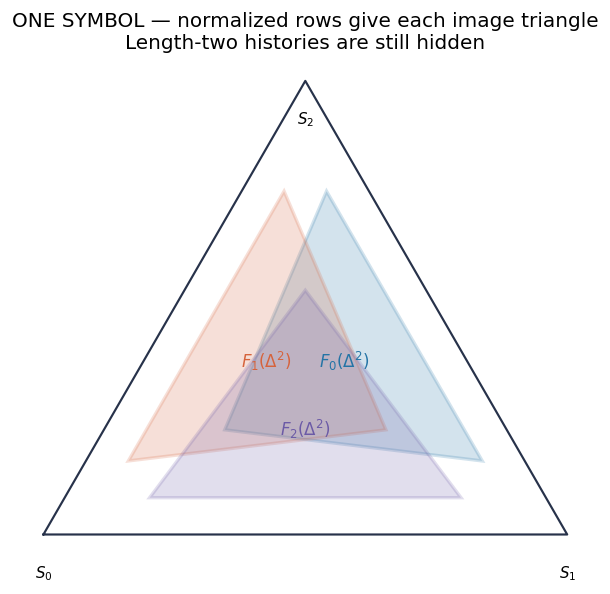

In [6]:
# CORE VISUAL 1 — one-symbol image triangles only. Run; do not edit.
from matplotlib.patches import Polygon

mess3_T = np.array([
    [[.14,.06,.06], [.03,.28,.06], [.03,.06,.28]],
    [[.28,.03,.06], [.06,.14,.06], [.06,.03,.28]],
    [[.28,.06,.03], [.06,.28,.03], [.06,.06,.14]],
], dtype=float)
mess3_initial = np.ones(3) / 3
map_colors = ["#2474a6", "#d6633c", "#6b5aa6"]

fig, ax = plt.subplots(figsize=(6.7, 5.4))
ax.plot(triangle[:, 0], triangle[:, 1], color="#27324a", lw=1.3)
for label, xy in zip([r"$S_0$", r"$S_1$", r"$S_2$"],
                     simplex_vertices):
    ax.text(*(xy + np.array([0.0, -.055])), label,
            ha="center", va="top", fontsize=9)

for symbol in range(3):
    mapped_beliefs = mess3_T[symbol] / (
        mess3_T[symbol].sum(axis=1, keepdims=True)
    )
    mapped_vertices = mapped_beliefs @ simplex_vertices
    ax.add_patch(Polygon(
        mapped_vertices, closed=True,
        facecolor=map_colors[symbol], edgecolor=map_colors[symbol],
        alpha=.20, lw=2,
    ))
    center = mapped_vertices.mean(axis=0)
    ax.text(
        *center, rf"$F_{symbol}(\Delta^2)$",
        ha="center", va="center", fontsize=10,
        color=map_colors[symbol], fontweight="bold",
    )

ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    "ONE SYMBOL — normalized rows give each image triangle\n"
    "Length-two histories are still hidden",
    fontsize=12,
)
plt.show()


Now do one composition before the reveal.

1. Normalize the three rows of $T^{(0)}$ to calculate
   $F_0(e_0)$, $F_0(e_1)$, and $F_0(e_2)$. Match them to the
   vertices of the blue image triangle.
2. Starting from the uniform belief, calculate $\eta^{(0)}$ and then
   $\eta^{(01)}=F_1(\eta^{(0)})$.
3. On the one-symbol visual, identify the image triangle that must
   contain $\eta^{(01)}$. Explain why the **last** observed symbol,
   rather than the first, determines that outer triangle.
4. Sketch the qualitative placement of the other eight length-two
   histories. Then predict what repeated compositions will do.
5. Does having three hidden generator states constrain the observer
   to only three predictive states?

<details><summary>Hint</summary>
For a history `01`, apply $F_0$ first and $F_1$ second. Every point
produced by the second map lies in $F_1(\Delta^2)$.
</details>


#### Worked solution

Normalizing the rows of $T^{(0)}$ gives

$$
F_0(e_0)=(7,3,3)/13,\quad
F_0(e_1)=(3,28,6)/37,\quad
F_0(e_2)=(3,6,28)/37.
$$

From the uniform initial belief,

$$
\eta^{(0)}=(1/5,2/5,2/5).
$$

Propagating through $T^{(1)}$ gives an unnormalized row
$(.104,.074,.148)$, hence

$$
\eta^{(01)}=(52,37,74)/163
\approx(.319,.227,.454).
$$

Because $F_1$ is applied last, this point must lie inside the orange
triangle $F_1(\Delta^2)$. More generally, histories sharing their
last symbol occupy the same outer image triangle; the earlier symbol
selects a smaller image within it. Repetition nests these images and
produces many, potentially fractal, observer states. Three hidden
generator states fix the ambient simplex, not the number of reachable
posterior beliefs.


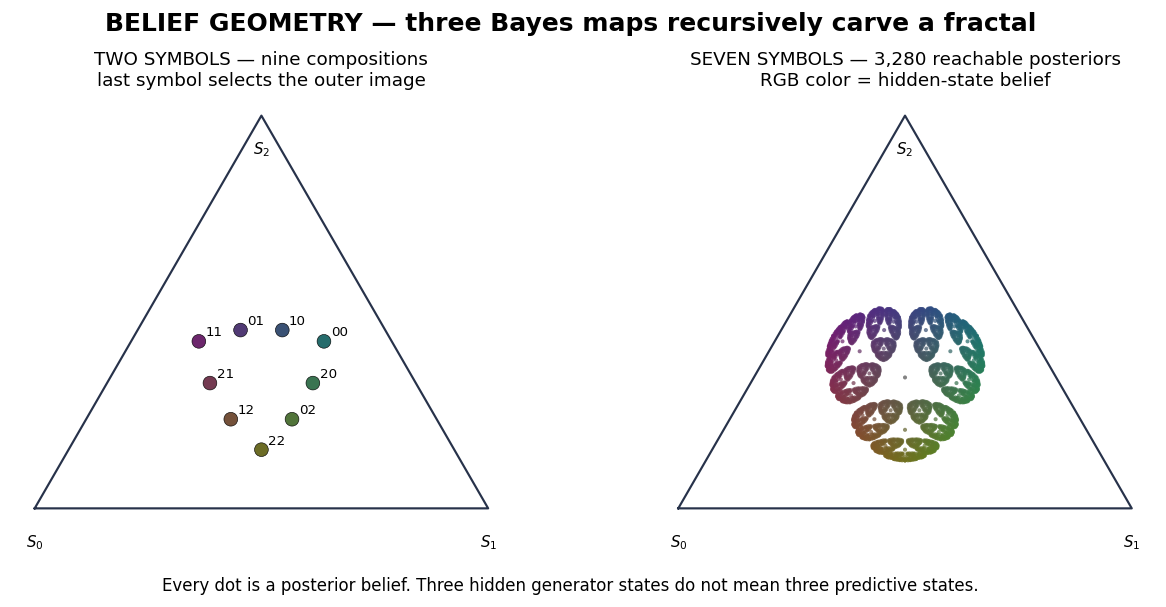

In [7]:
# CORE VISUAL 2 — reveal the recursive layer and the final geometry.
mess3_beliefs = reachable_beliefs(
    [0, 1, 2], 7, mess3_initial, mess3_T
)
B = np.array(list(mess3_beliefs.values()))
XY = B @ simplex_vertices

fig, axes = plt.subplots(1, 2, figsize=(10.8, 5.0))
for ax in axes:
    ax.plot(triangle[:, 0], triangle[:, 1],
            color="#27324a", lw=1.3)
    for label, xy in zip([r"$S_0$", r"$S_1$", r"$S_2$"],
                         simplex_vertices):
        ax.text(*(xy + np.array([0.0, -.055])), label,
                ha="center", va="top", fontsize=9)
    ax.set_aspect("equal")
    ax.axis("off")

depth2_words = list(itertools.product(range(3), repeat=2))
depth2_B = np.array([
    belief("".join(map(str, word)), mess3_initial, mess3_T)
    for word in depth2_words
])
depth2_XY = depth2_B @ simplex_vertices
axes[0].scatter(
    depth2_XY[:, 0], depth2_XY[:, 1],
    c=np.clip(depth2_B, 0, 1), s=68,
    edgecolor="black", linewidth=.35,
)
for word, xy in zip(depth2_words, depth2_XY):
    axes[0].annotate(
        "".join(map(str, word)), xy, xytext=(4, 3),
        textcoords="offset points", fontsize=8,
    )
axes[0].set_title(
    "TWO SYMBOLS — nine compositions\n"
    "last symbol selects the outer image",
    fontsize=11,
)

axes[1].scatter(
    XY[:, 0], XY[:, 1], c=np.clip(B, 0, 1),
    s=6, alpha=.72, linewidth=0,
)
axes[1].set_title(
    f"SEVEN SYMBOLS — {len(B):,} reachable posteriors\n"
    "RGB color = hidden-state belief",
    fontsize=11,
)
fig.suptitle(
    "BELIEF GEOMETRY — three Bayes maps recursively carve a fractal",
    fontsize=15, fontweight="bold",
)
fig.text(
    .5, .015,
    "Every dot is a posterior belief. Three hidden generator states "
    "do not mean three predictive states.",
    ha="center", fontsize=10,
)
fig.subplots_adjust(
    left=.04, right=.98, bottom=.12, top=.84, wspace=.12
)
plt.show()


## Synthesis

Complete the chain in words, not just symbols:

$$
\text{HMM edges}
\longrightarrow \Pr(w)
\longrightarrow \eta^{(w)}
\longrightarrow F_x
\longrightarrow \text{belief geometry}
\longrightarrow \Pr(\text{future}\mid\eta).
$$

Which arrows are linear, which require normalization, and which
describe a change of interpretation rather than a new calculation?


#### Worked solution

Symbol-labelled matrices encode the edges. Their products sum hidden
paths and give word probabilities. Keeping the final hidden state
unsummed gives an unnormalized forward vector; dividing by its mass
turns it into a posterior belief. Reusing that posterior as the next
prior gives the normalized update maps $F_x$. Iterating those maps
produces geometry in the simplex. Finally, multiplying a belief by
future symbol matrices and summing gives any future probability.

Matrix propagation and the belief-to-future map are linear before
normalization. Bayesian updates are generally nonlinear because
their denominators depend on the current belief. “Belief geometry”
is the same collection of posteriors viewed geometrically, not a
separate probabilistic object.


## Optional design studio — tune rather than start from nothing

The supplied family has a cyclic `0` skeleton:

$$
S_0\xrightarrow{0:a}S_1,\quad
S_1\xrightarrow{0:b}S_2,\quad
S_2\xrightarrow{0:c}S_0,
$$

with a `1` self-loop carrying the remaining probability at each
state.

Choose one brief and its starting preset:

| Brief | Start from $(a,b,c)$ | Operational target |
|---|---|---|
| **fast synchronization** | $(.95,.55,.08)$ | median posterior entropy below $0.35$ nats by depth 8 |
| **persistent ambiguity** | $(.62,.52,.42)$ | median entropy above $0.70$ nats and no single coordinate above $.95$ |
| **branching geometry** | $(.88,.50,.15)$ | the centroids after final symbol `0` versus `1` are far apart |

1. Predict which parameters make an observed `0` most diagnostic.
2. Run the matching preset and compare the printed metrics with its
   target.
3. Change **one parameter**, state the direction in which each metric
   should move, and rerun.
4. Report one failed prediction or one tradeoff between the targets.

The metrics are only handles for reasoning, not canonical measures
of geometric complexity.


In [8]:
# OPTIONAL DESIGN CELL — pick a preset, then edit one number.
a, b, c = 0.88, 0.50, 0.15  # branching-geometry preset


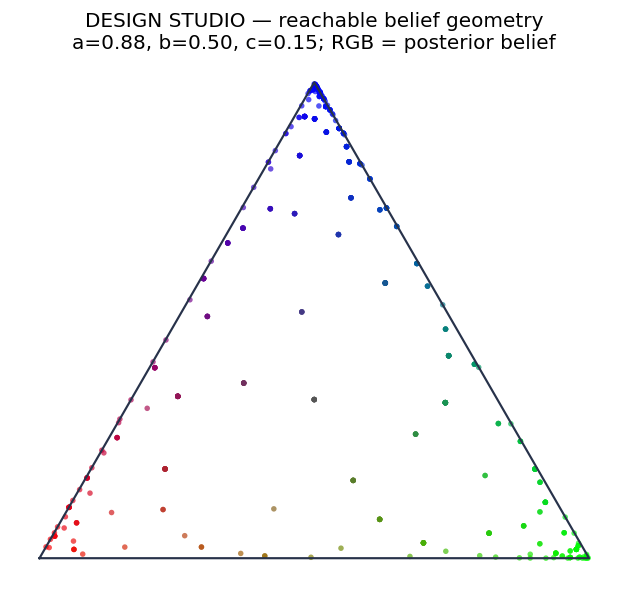

stationary initial belief: [0.1159 0.204  0.6801]
median posterior entropy (nats): 0.5124484948629559
largest posterior coordinate: 0.998175519706804
last-symbol centroid separation: 0.3865838040870767


In [9]:
# PROVIDED VISUALIZER — run after choosing a, b, and c.

def noisy_cycle(a, b, c):
    assert all(0 <= z <= 1 for z in (a, b, c))
    symbol_0 = np.array([
        [0, a, 0],
        [0, 0, b],
        [c, 0, 0],
    ], dtype=float)
    symbol_1 = np.diag([1-a, 1-b, 1-c])
    return np.stack([symbol_0, symbol_1])

custom_T = noisy_cycle(a, b, c)
state_T = custom_T.sum(axis=0)
evals, evecs = np.linalg.eig(state_T.T)
custom_initial = np.real(evecs[:, np.argmin(np.abs(evals - 1))])
custom_initial = custom_initial / custom_initial.sum()

custom_beliefs = reachable_beliefs(
    [0, 1], 8, custom_initial, custom_T
)
C = np.array(list(custom_beliefs.values()))
Cxy = C @ simplex_vertices

fig, ax = plt.subplots(figsize=(6.5, 5.7))
ax.plot(triangle[:, 0], triangle[:, 1], color="#27324a", lw=1.3)
ax.scatter(Cxy[:, 0], Cxy[:, 1], c=np.clip(C, 0, 1), s=11,
           alpha=.68, linewidth=0)
ax.set_title(
    "DESIGN STUDIO — reachable belief geometry\n"
    f"a={a:.2f}, b={b:.2f}, c={c:.2f}; RGB = posterior belief"
)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

safe_C = np.clip(C, 1e-15, 1)
entropies = -(safe_C * np.log(safe_C)).sum(axis=1)
histories_custom = list(custom_beliefs)
last_zero = np.array([
    custom_beliefs[w] for w in histories_custom if w.endswith("0")
])
last_one = np.array([
    custom_beliefs[w] for w in histories_custom if w.endswith("1")
])
centroid_gap = np.linalg.norm(
    last_zero.mean(axis=0) - last_one.mean(axis=0)
)
print("stationary initial belief:", custom_initial)
print("median posterior entropy (nats):", np.median(entropies))
print("largest posterior coordinate:", C.max())
print("last-symbol centroid separation:", centroid_gap)


### Exit ticket

In two sentences: why can prediction be geometrically more
complicated than generation, even when the data-generating HMM has
only three hidden states?
